In [6]:
import iohinspector

manager = iohinspector.DataManager()
manager.add_folder(f"experiments_20250531_233020")
manager.add_folder(f"experiments_20250603_184706")
manager.add_folder(f"plot-experiments/PCA-BO")

In [7]:
manager.overview

data_id,algorithm_name,algorithm_info,suite,function_name,function_id,dimension,instance,run_id,evals,best_y,pca_components,var_threshold
u64,str,str,str,str,u16,u16,u16,u32,u64,f64,i64,f64
2828,"""linearPCABO""","""""","""unknown_suite""","""Sphere""",1,20,0,1,1000,62.31824,null,null
2829,"""linearPCABO""","""""","""unknown_suite""","""Sphere""",1,40,0,1,1000,180.184009,null,null
2830,"""linearPCABO""","""""","""unknown_suite""","""Sphere""",1,20,10,1,1000,62.146582,null,null
2831,"""linearPCABO""","""""","""unknown_suite""","""Sphere""",1,40,10,1,1000,143.370661,null,null
2832,"""linearPCABO""","""""","""unknown_suite""","""Sphere""",1,20,11,1,1000,107.587314,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…
663,"""clean-pca""","""A clean-pca-BO Implementation.""","""BBOB""","""RosenbrockRotated""",9,40,5,6,450,29973.322951,0,0.95
664,"""clean-pca""","""A clean-pca-BO Implementation.""","""BBOB""","""RosenbrockRotated""",9,40,6,7,450,40922.850977,0,0.95
665,"""clean-pca""","""A clean-pca-BO Implementation.""","""BBOB""","""RosenbrockRotated""",9,40,7,8,450,40818.309298,0,0.95


In [8]:

from iohinspector import DataManager
import polars as pl


def load(
    self: DataManager,
    monotonic: bool = True,
    include_meta_data: bool = False,
    include_columns: list[str] = None,
    x_values: list[str] = None
) -> pl.DataFrame:
    if not self.any:
        return pl.DataFrame()

    data = []
    common_columns = None

    # First pass: collect data and track common columns
    for data_set in self.data_sets:
        for scen in data_set.scenarios:
            df = scen.load(monotonic, data_set.function.maximization, x_values)

            if common_columns is None:
                common_columns = set(df.columns)
            else:
                common_columns &= set(df.columns)

            data.append(df)

    # Convert common_columns to a list
    common_columns = list(common_columns)

    # Second pass: keep only common columns
    data = [df.select(common_columns) for df in data]
    data = pl.concat(data)

    if include_meta_data or include_columns is not None:
        if include_columns is None:
            include_columns = self.overview.columns

        for c in ("data_id", "run_id",):
            if c not in include_columns:
                include_columns.append(c)
        
        data = self.overview.select(include_columns).join(
            data, on=("data_id", "run_id")
        )
    return data

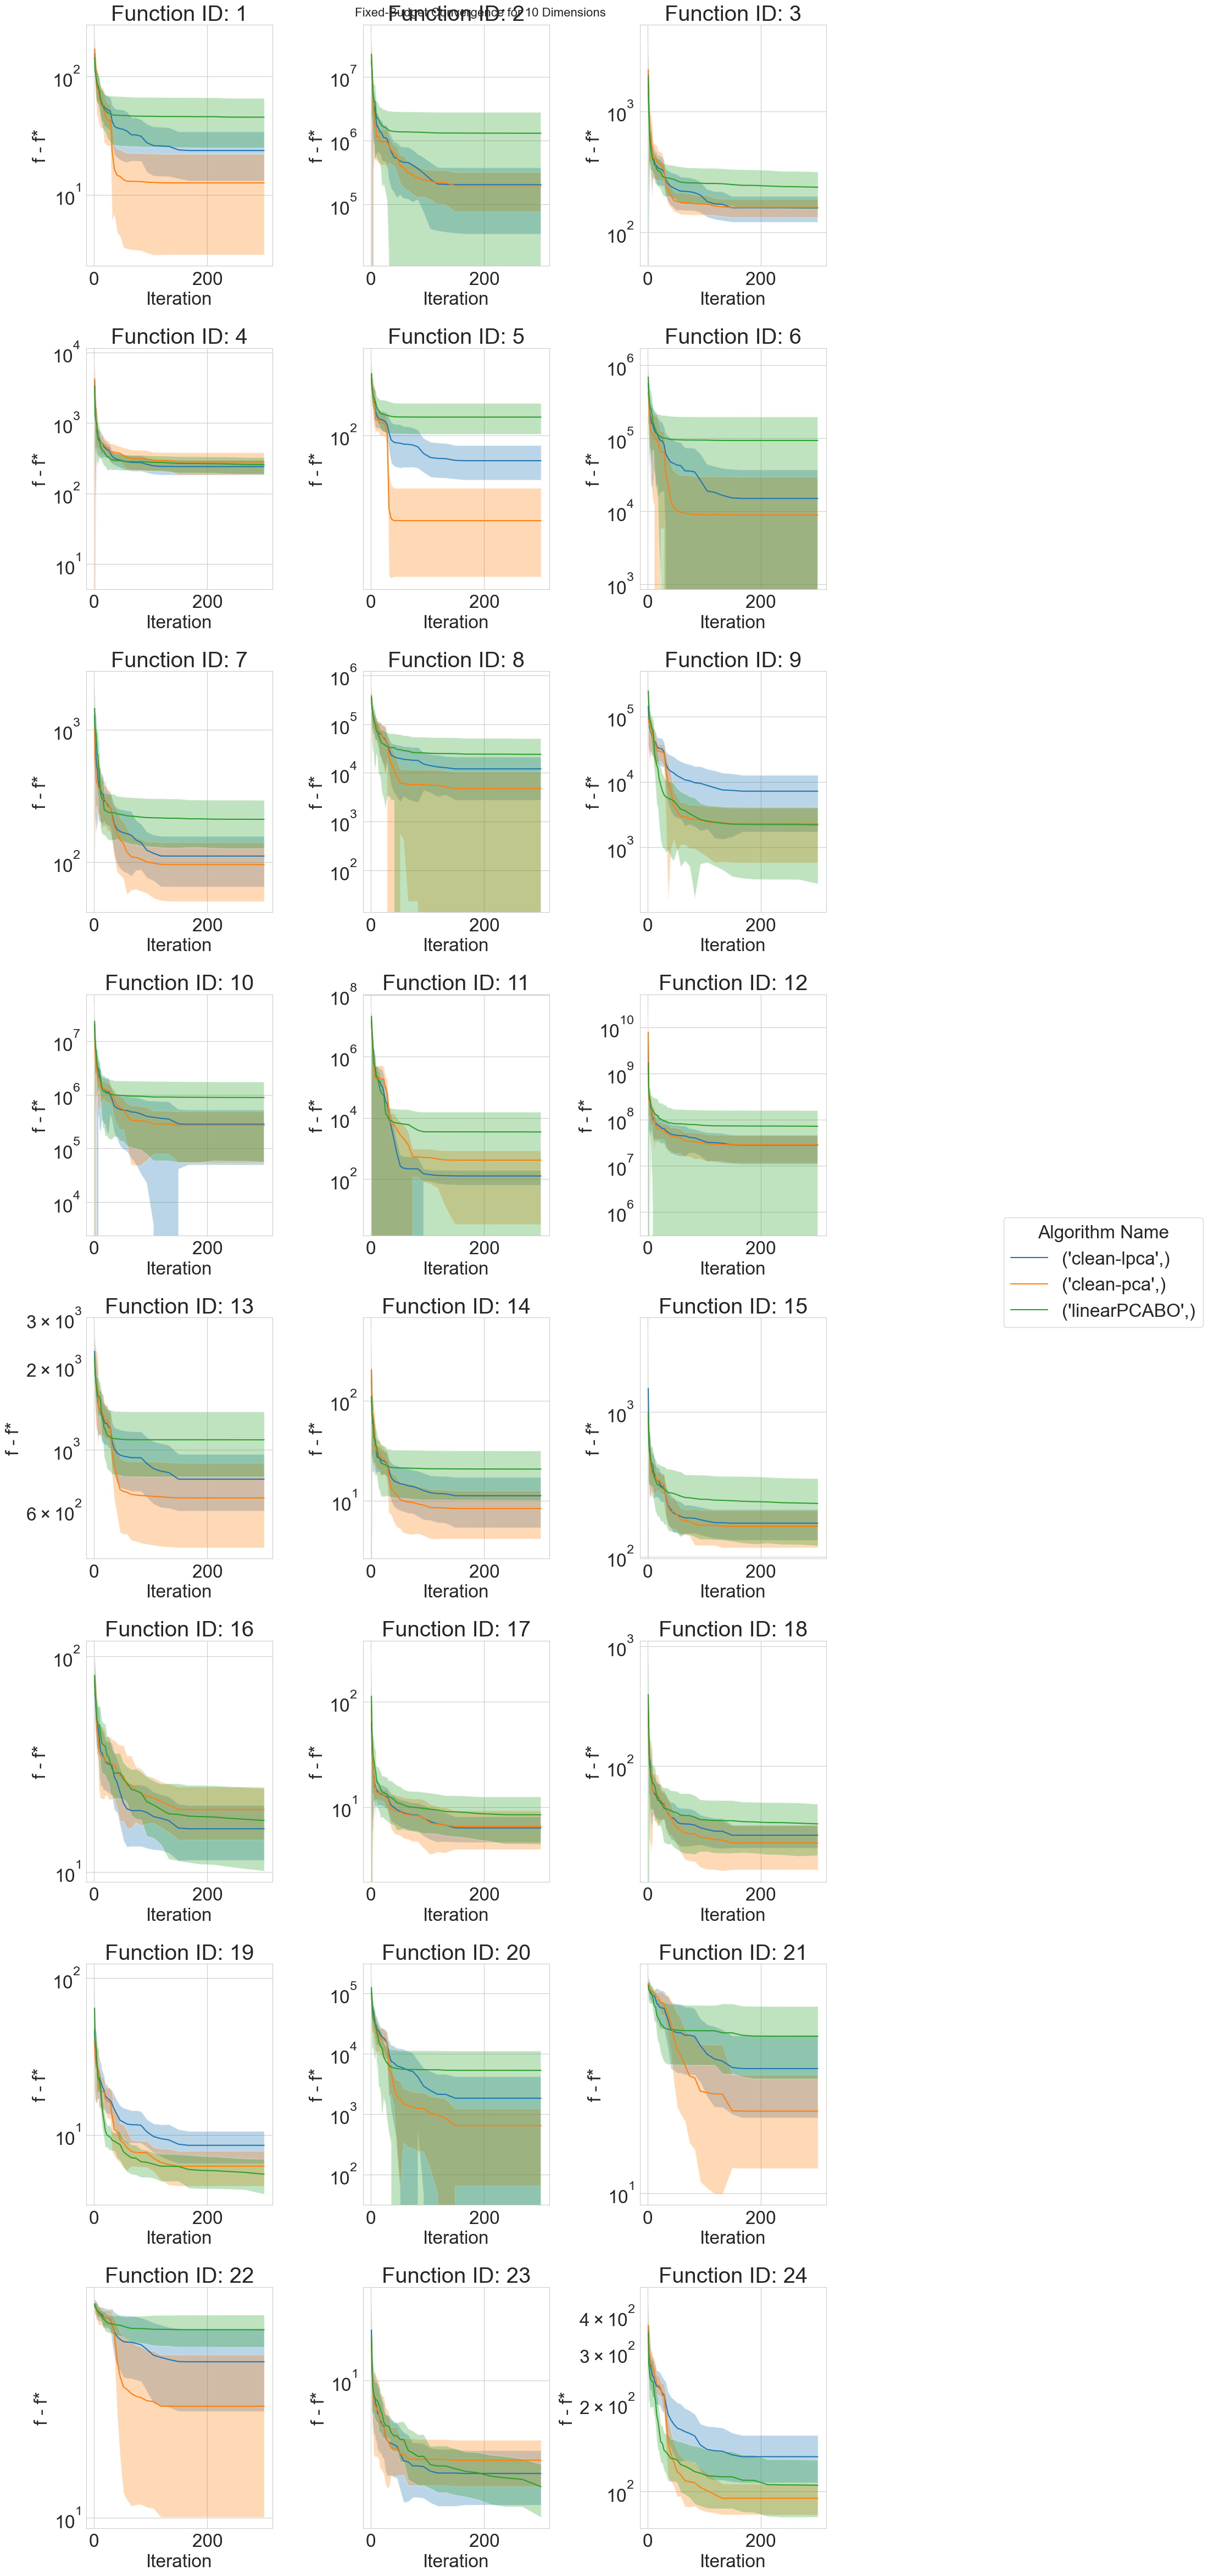

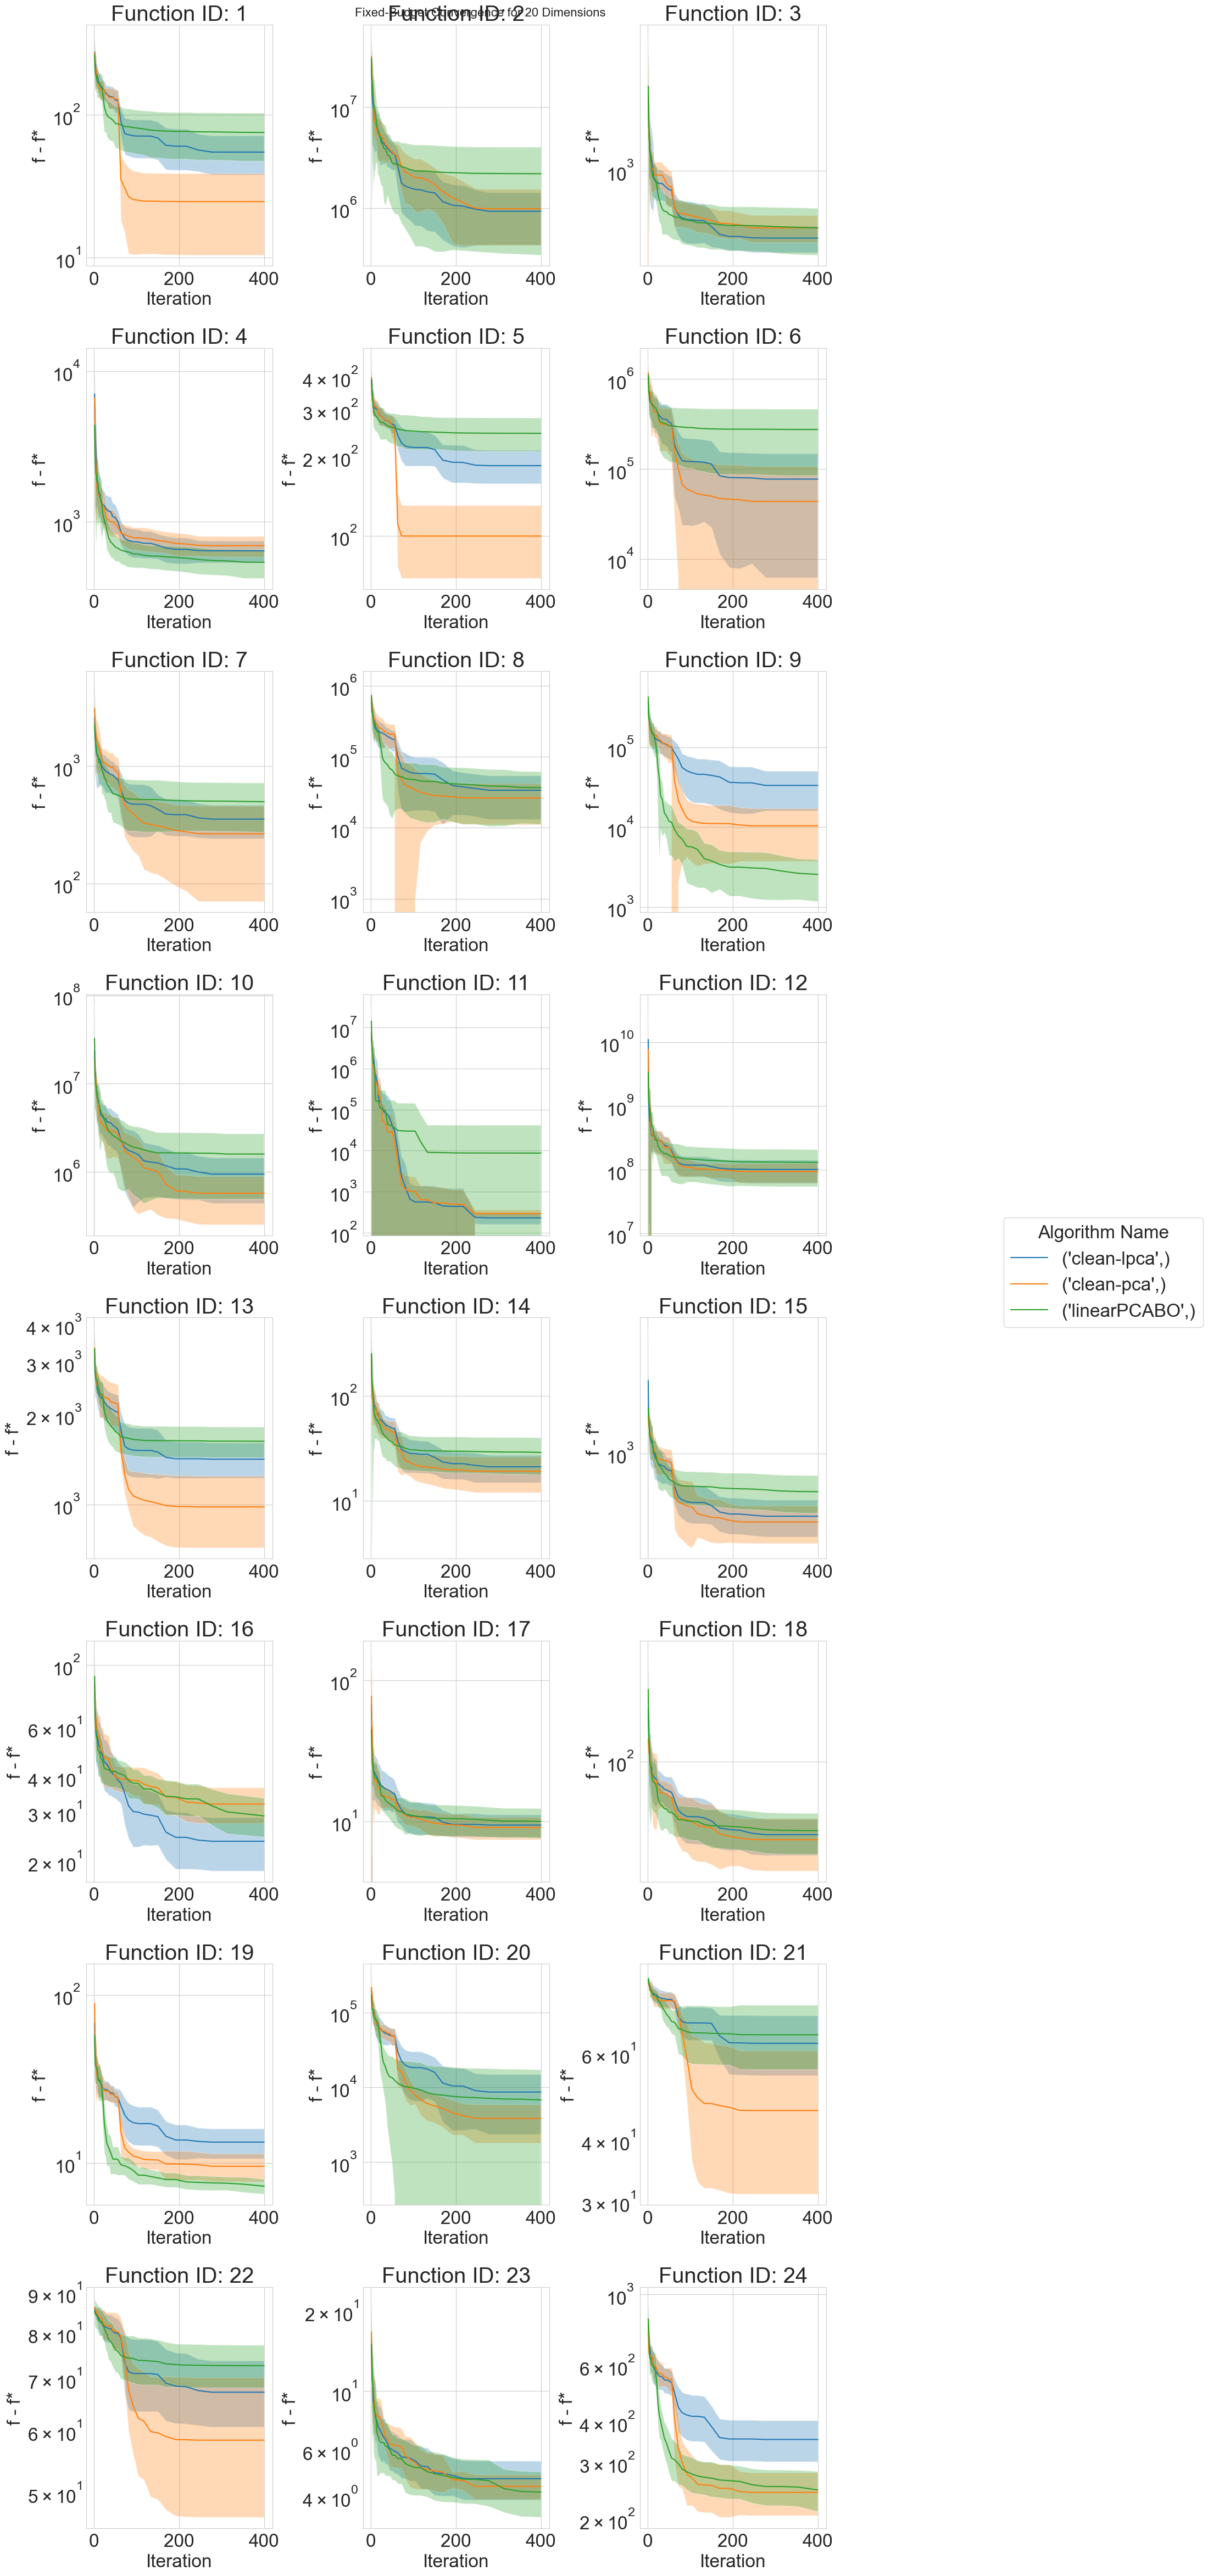

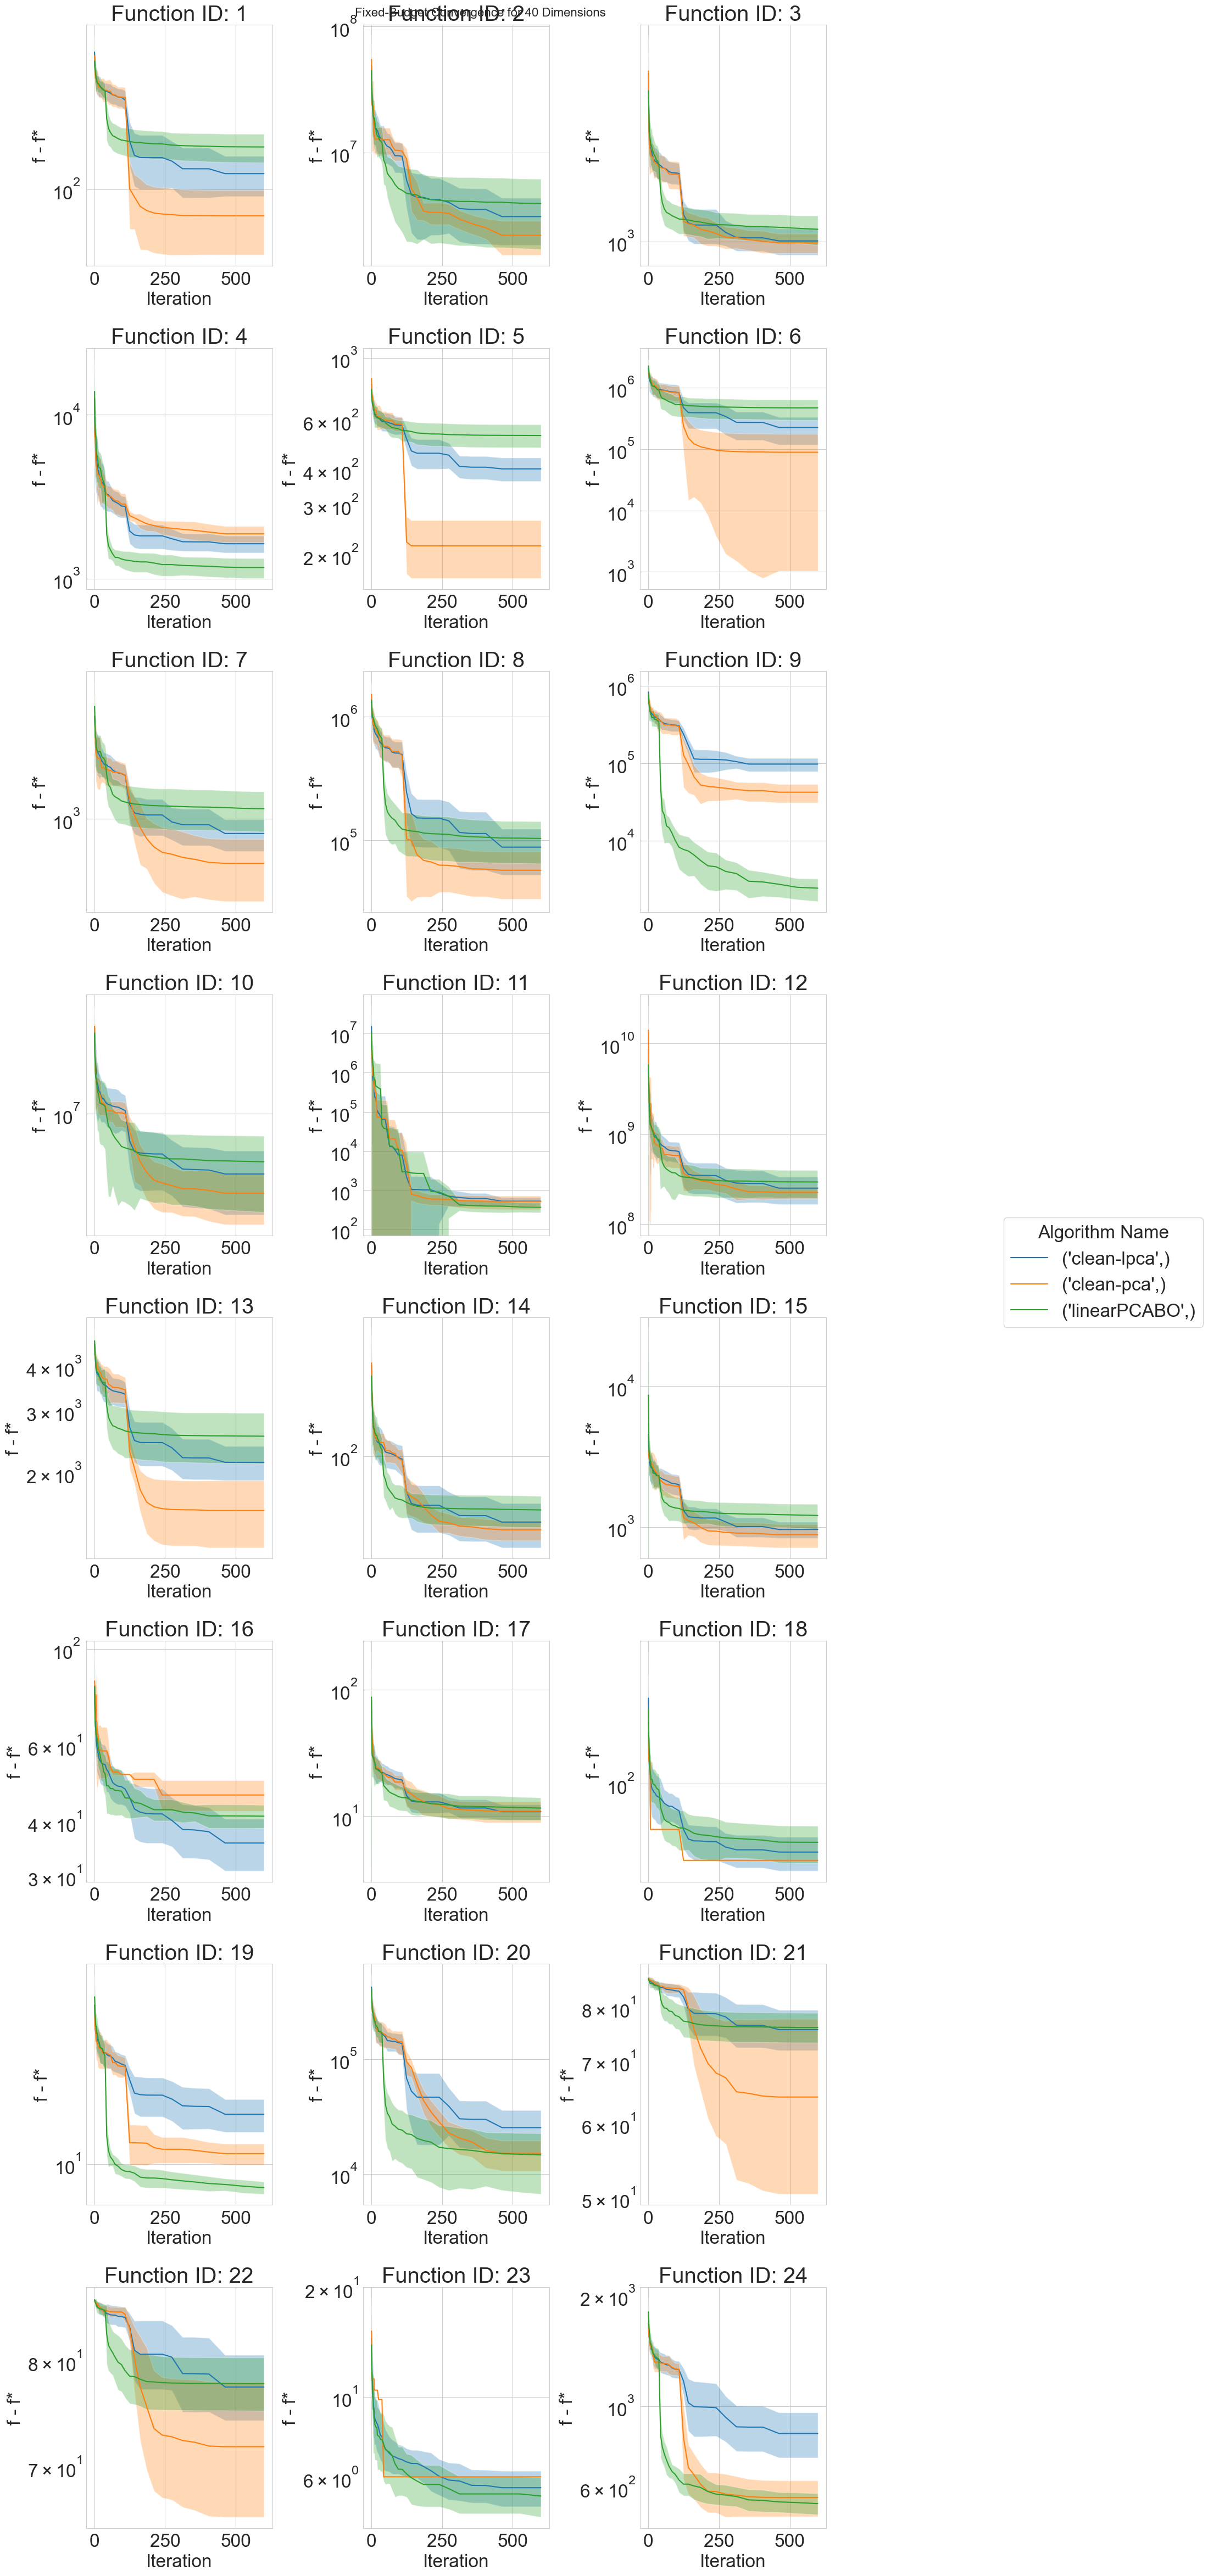

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from iohinspector import aggegate_convergence
import matplotlib
from typing import Iterable
import polars as pl


def single_function_fixedbudget(
    data: pl.DataFrame,
    evaluation_variable: str = "evaluations",
    fval_variable: str = "raw_y",
    free_variables: Iterable[str] = ["algorithm_name"],
    x_min: float = None,
    x_max: float = None,
    maximization: bool = False,
    measures: Iterable[str] = ["geometric_mean"],
    scale_xlog: bool = False,
    scale_ylog: bool = False,
    ax: matplotlib.axes._axes.Axes = None,
    file_name: str = None,
):
    """Create a fixed-budget plot for a given set of performance data.

    Args:
        data (pl.DataFrame): The DataFrame which contains the full performance trajectory. Should        be generated from a DataManager.
        evaluation_variable (str, optional): Column in 'data' which corresponds to the number of evaluations. Defaults to "evaluations".
        fval_variable (str, optional): Column in 'data' which corresponds to the performance measure. Defaults to "raw_y".
        free_variables (Iterable[str], optional): Columns in 'data' which correspond to the variables which will be used to distinguish between lines in the plot. Defaults to ["algorithm_name"].
        x_min (float, optional): Minimum value to use for the 'evaluation_variable', if not present the min of that column will be used. Defaults to None.
        x_max (float, optional): Maximum value to use for the 'evaluation_variable', if not present the max of that column will be used. Defaults to None.
        maximization (bool, optional): Boolean indicating whether the 'fval_variable' is being maximized. Defaults to False.
        measures (Iterable[str], optional): List of measures which should be used in the plot. Valid options are 'geometric_mean', 'mean', 'median', 'min', 'max'. Defaults to ['geometric_mean'].
        scale_xlog (bool, optional): Should the x-axis be log-scaled. Defaults to True.
        scale_ylog (bool, optional): Should the y-axis be log-scaled. Defaults to True.
        ax (matplotlib.axes._axes.Axes, optional): Existing matplotlib axis object to draw the plot on.
        file_name (str, optional): Where should the resulting plot be stored. Defaults to None. If existing axis is provided, this functionality is disabled.

    Returns:
        pd.DataFrame: The final dataframe which was used to create the plot
    """
    dt_agg = aggegate_convergence(
        data,
        evaluation_variable=evaluation_variable,
        fval_variable=fval_variable,
        free_variables=free_variables,
        x_min=x_min,
        x_max=x_max,
        maximization=maximization,
    )

    dt_molt = dt_agg.melt(id_vars=[evaluation_variable] + free_variables)
    dt_plot = dt_molt[dt_molt["variable"].isin(measures)].sort_values(free_variables)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    # sns.lineplot(
    #     dt_agg,
    #     x=evaluation_variable,
    #     y="mean",
    #     #style="variable",
    #     #errorbar="sd",
    #     hue="algorithm_name",
    #     ax=ax,
    # )
    
    for name, group in dt_agg.groupby(free_variables):
        ax.plot(group[evaluation_variable], group["mean"], label=name)
        ax.fill_between(
        group[evaluation_variable],
        group["mean"] - group["std"],
        group["mean"] + group["std"],
        alpha=0.3
        )
    x = dt_agg[evaluation_variable]
    y = dt_agg["mean"]
    std = dt_agg["std"]

    #ax.plot(x, y)

    # if std is not None:
    #     ax.fill_between(x, y - std, y + std, alpha=0.3,
    #     hue=dt_agg["algorithm_name"],)
    if scale_xlog:
        ax.set_xscale("log")
    if scale_ylog:
        ax.set_yscale("log")

    # if not maximization:
    #     ax.set_xlim(ax.get_xlim()[::-1])

    if ax is None and file_name:
        fig.tight_layout()
        fig.savefig(file_name)

    return dt_plot

# Define function IDs and dimensions
function_ids = list(range(1, 25))
dimensions = [10, 20, 40]

# Loop through dimensions
for dimension in dimensions:
    # Create a figure with subplots based on number of functions
    num_funcs = len(function_ids)
    rows = (num_funcs + 2) // 3  # Calculate number of rows (3 plots per row)
    cols = min(3, num_funcs)  # Use up to 3 columns

    # Create figure with extra width to accommodate the shared legend
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    fig.suptitle(f'Fixed-Budget Convergence for {dimension} Dimensions', fontsize=16)



    if cols == 1:
        axes = [axes]

    # Flatten axes for easier iteration if multiple rows
    axes_flat = axes.flatten() if num_funcs > 3 else axes

    # Store handles and labels for shared legend
    all_handles = []
    all_labels = []

    # Loop through function IDs
    for idx, func_id in enumerate(function_ids):
        #try:
        selection = manager.select(function_ids=[func_id], dimensions=[dimension])
        df = load(selection, False, True)
        #except: 
        #    continue
        # df = iohinspector.metrics.add_normalized_objectives(df, obj_cols=['raw_y', 'raw_y_best'])
        # evals = iohinspector.metrics.get_sequence(5, 190, 200, cast_to_int=False, scale_log=True)
        # hv_indicator = iohinspector.indicators.anytime.HyperVolume(reference_point=[1.1, 1.1])
        # df_hv = iohinspector.indicators.add_indicator(df, hv_indicator,
        #                                               objective_columns=['obj1', 'obj2'],
        #                                               evals=evals)
        # 
        # # Create subplot
        # g = sns.lineplot(data=df_hv.to_pandas(), x='evaluations', y=hv_indicator.var_name,
        #                  hue='algorithm_name', ax=axes_flat[idx])
        try:
            single_function_fixedbudget(df, ax=axes_flat[idx], measures=["min", "max", "mean"], x_max=200 + 10 * dimension, scale_ylog=True)
        except (Exception) as e:
            print(e)

        # Store handles and labels from first plot only
        if idx == 0:
            all_handles, all_labels = axes_flat[idx].get_legend_handles_labels()

        # Remove individual legend from each subplot
        # axes_flat[idx].get_legend().remove()

        axes_flat[idx].set_title(f'Function ID: {func_id}')
        axes_flat[idx].set_xlabel('Iteration')
        axes_flat[idx].set_ylabel(f'f - f*')

    # Remove empty subplots if any
    for idx in range(len(function_ids), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    # Add single shared legend for entire figure
    fig.legend(all_handles, all_labels,
               bbox_to_anchor=(1.02, 0.5),  # Position legend to the right of all subplots
               loc='center left',  # Anchor the legend on its left side
               title='Algorithm Name',  # Add a title to the legend
               fontsize='medium',  # Control font size
               title_fontsize='medium')  # Control title font size

    # Adjust layout to prevent overlapping while leaving space for legend
    plt.tight_layout()
    # Adjust figure to make room for the legend
    fig.subplots_adjust(right=0.85)  # Adjust this value to change legend position
    plt.show()